Make plots for CFC-CCA talk

In [5]:
import numpy as np
from scipy.interpolate import make_interp_spline
import importlib
from matplotlib import rcParams
plt.style.use('/Users/eb35267/Desktop/mpl_style/pres_style.mplstyle')

# Adapted from Shen+

In [20]:
# Extracted data

# Theoretical curve
curve = np.array([-16.091627152579992, -2.215513631389835,
-16.275905849119567, -2.3625789829035284,
-16.341699713636046, -2.4238189621052793,
-16.447025772755847, -2.497396338576872,
-16.55232389392893, -2.5831770101740688,
-16.776134785071825, -2.742579758957604,
-16.920909224954794, -2.8651044180758514,
-17.052552829881186, -2.9631777862281443,
-17.26317701017407, -3.122535834296934,
-17.65796813521966, -3.477772414381834,
-17.78958380219934, -3.5880490776597314,
-17.960647849942184, -3.7472730235842833,
-18.131683959738314, -3.9187002646344395,
-18.38170064490094, -4.151412185601092,
-18.63166145417013, -4.408530696818954,
-18.80269756396626, -4.579957937869111,
-18.921098582149206, -4.702393195557867,
-19.09210675399862, -4.886023731733627,
-19.368273357287535, -5.216451415134607,
-19.47348766462047, -5.338841972108616,
-19.618150352716576, -5.510179811729281,
-19.736523432952808, -5.644818364543641,
-19.868027348145617, -5.803908208323955,
-19.973185779585123, -5.950705355549175,
-20.196661415367423, -6.256547645839962,
-20.328137392613517, -6.427840784745881,
-20.485875039772772, -6.648036505583709,
-20.604164306168855, -6.819284943774883,
-20.748659366584665, -7.063842554149174,
-20.84065902512087, -7.198391705534041,
-20.97210706442025, -7.3818881395655636,
-21.142863794749218, -7.675348331871765,
-21.234723763551845, -7.870913958884654,
-21.32672342208805, -8.005463110269524]).reshape(-1, 2)
curve[:,1] = 10**curve[:,1] # Take out of logspace

# Smoothing the curve data a little bit:
curve_x_new = np.linspace(curve[:,0].min(), curve[:,0].max(), 12)  # New x values for a smooth curve
sorting = np.argsort(curve[:,0])
spline = make_interp_spline(curve[:,0][sorting], curve[:,1][sorting], k=3)  # k is the degree of the spline
curve_y_smooth = spline(curve_x_new)

# Spectroscopically confirmed sources
spec_z = np.array([-18.711256664364374, -4.2013428839721545,
-20.107064420248804, -5.072515113653119,
-23.504849561917474, -6.999965232777419
]).reshape(-1, 2)
spec_z[:,1] = 10**spec_z[:,1] # Take out of logspace
# Error on those sources
yerr_lower = spec_z[:,1] - 10**np.array([-4.72, -5.51, -7.38])
yerr_upper = 10**np.array([-3.81, -4.67, -6.9]) - spec_z[:,1]
yerr = [yerr_lower, yerr_upper]

# Photometrically identified sources
phot_z = np.array([-17.3, -2.87,
-18.3, -3.21,
-17.9, -3.70,
-18.2, -3.86,
-18.3, -3.48,
-18.9, -3.63,
-18.9, -3.79,
-18.8, -3.74,
-19.6, -4.03,
-20.1, -4.12,
-19.2, -4.63,
-19.0, -4.57,
-20.1, -4.43,
-20.0, -4.51,
-20.2, -4.90,
-20.3, -4.71,
-20.4, -5.00,
-20.8, -4.92,
-21.0, -5.01,
-21.0, -5.47,
-21.2, -5.32,
-21.8, -5.91,
-22.2, -5.21,
-23.2, -5.25,
-22.6, -6.95,
-23.5, -7.46
]).reshape(-1,2)

phot_z[:,1] = 10**phot_z[:,1] # Take out of logspace

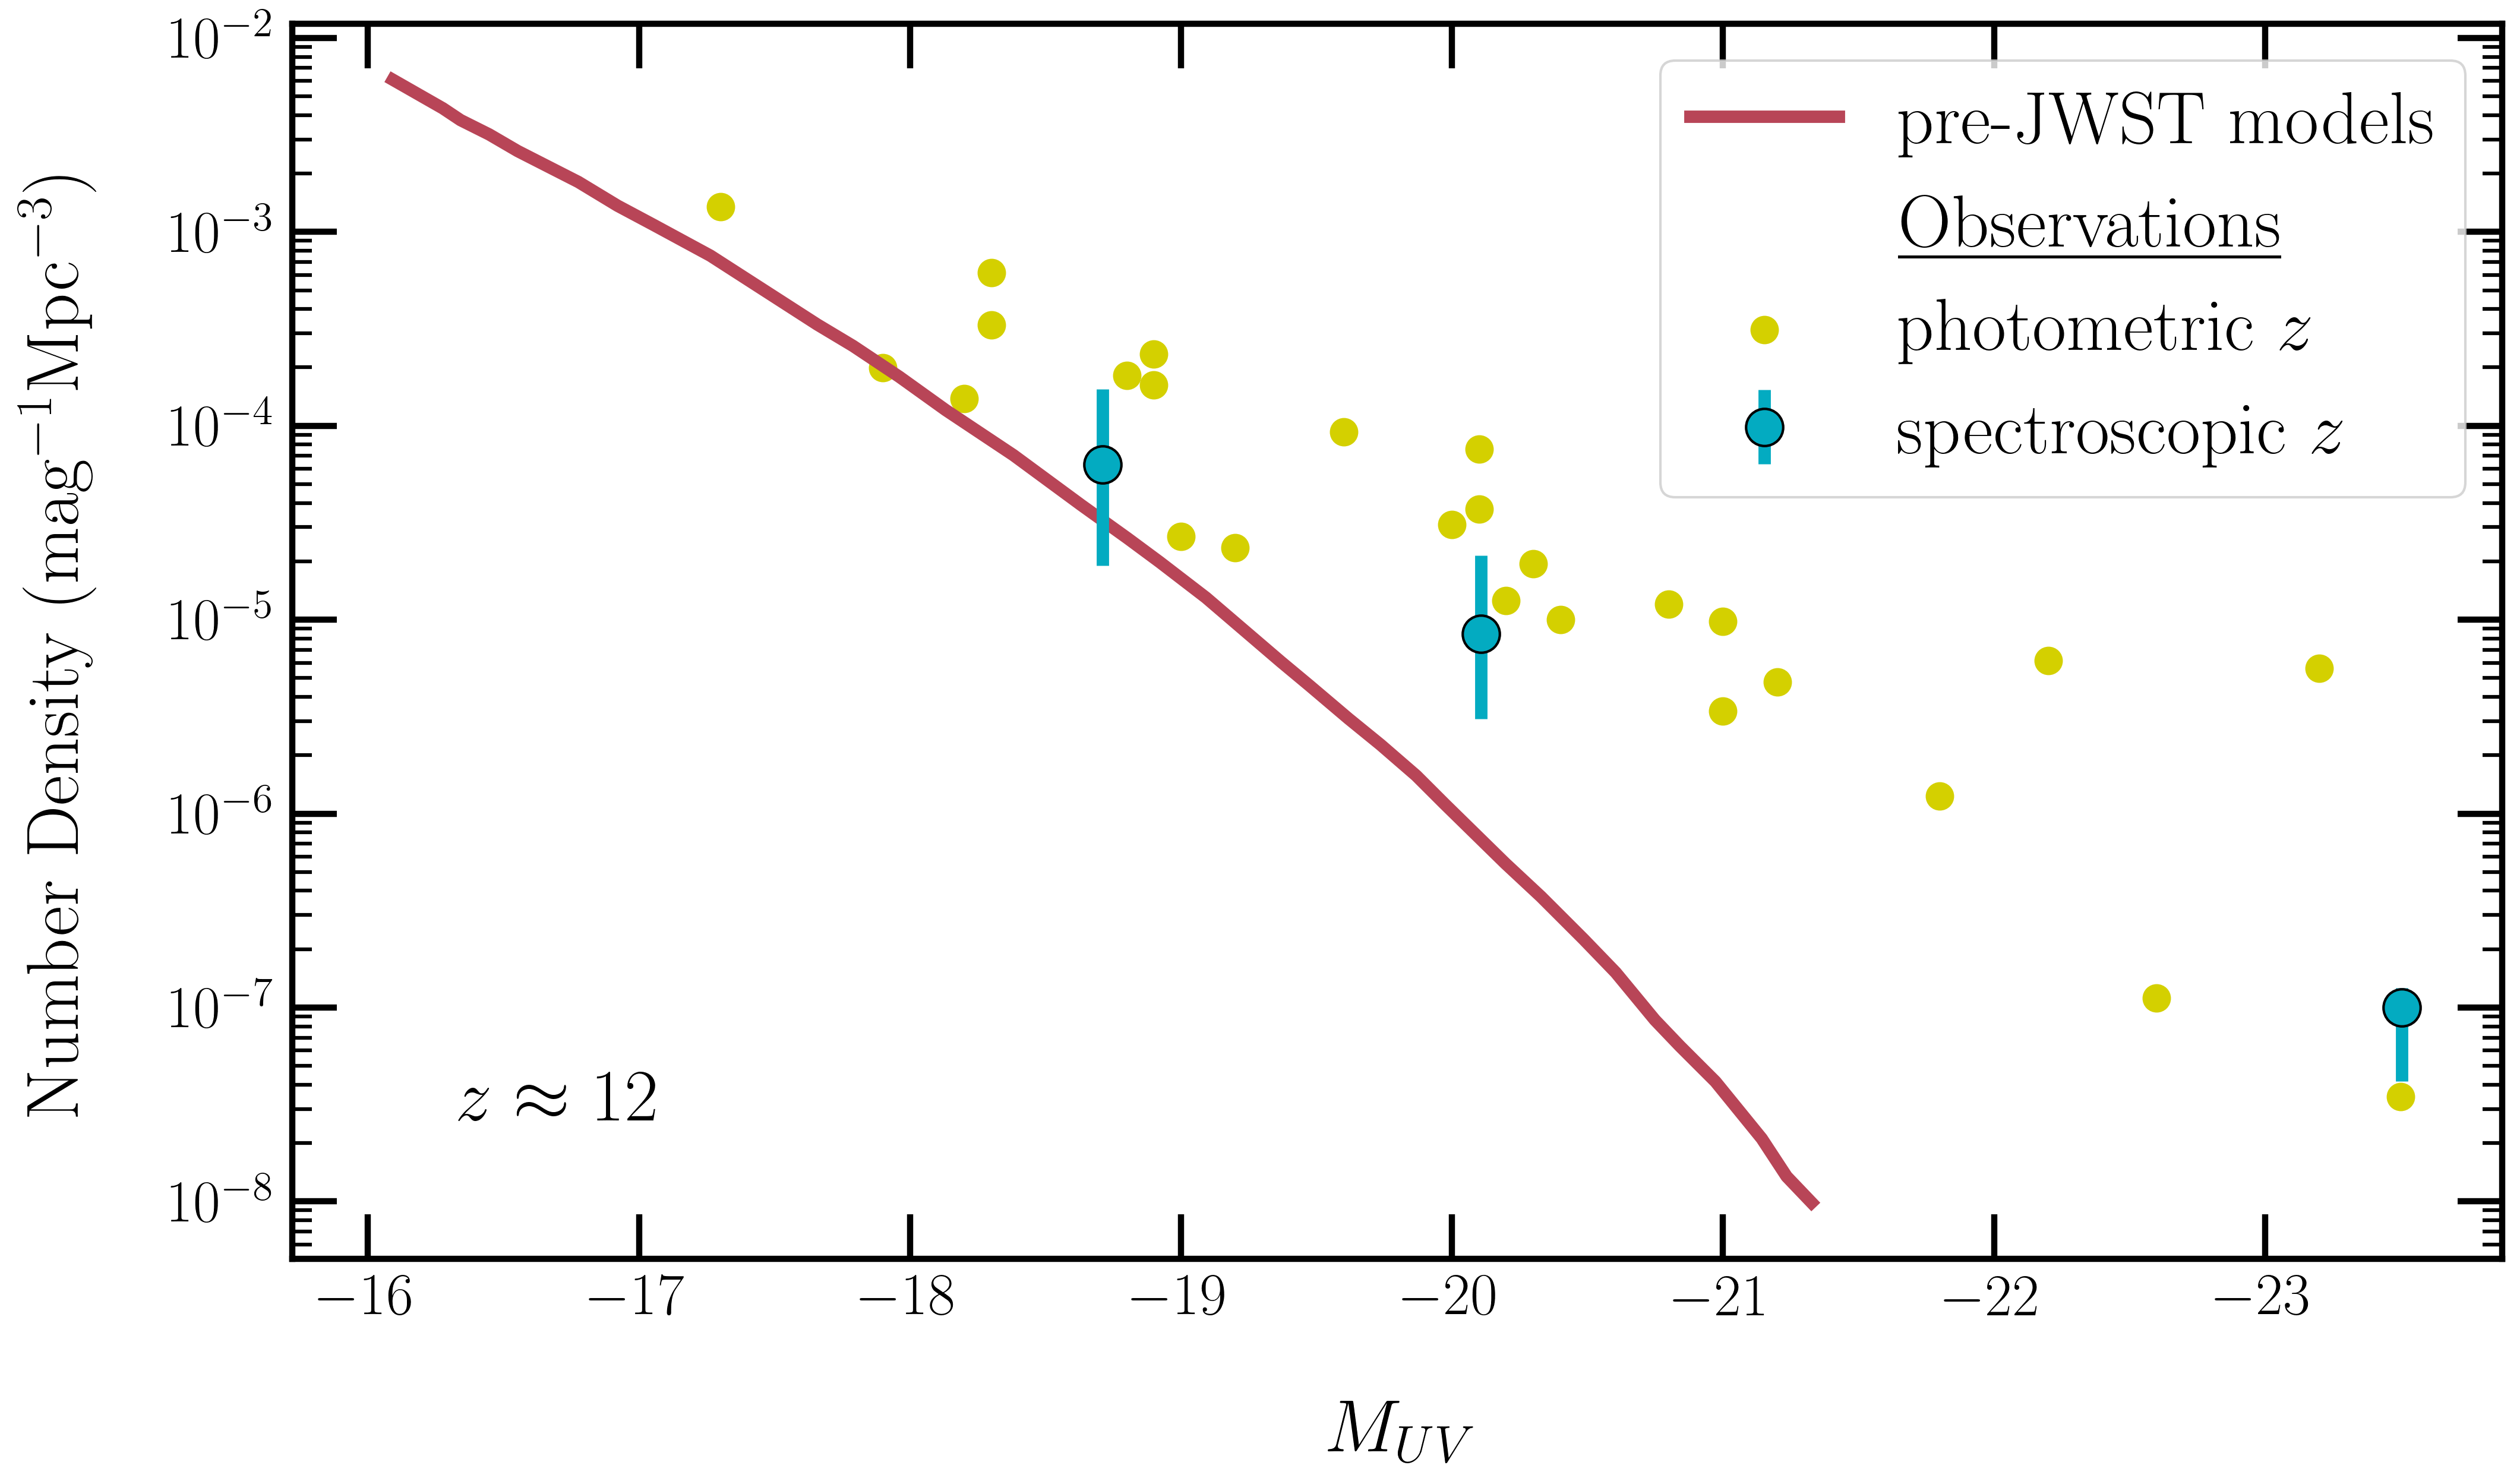

In [21]:
# Plot
rcParams['text.usetex'] = True # This will change font but allows us to underline
fig, ax = plt.subplots(figsize=(16, 9))

ax.plot(curve[:,0], curve[:,1], label = 'pre-JWST models')
plt.plot([], [], ' ', color = 'None', label = r'\underline{Observations}')
ax.errorbar(*spec_z.T, yerr = yerr, fmt = 'o', label = r'spectroscopic $z$')
ax.scatter(*phot_z.T, label = r'photometric $z$', s=110, color = '#d4d000')

ax.set_ylabel(r'Number Density (mag$^{-1}$Mpc$^{-3}$)')
ax.set_xlabel(r'$M_{UV}$')
plt.text(0.075, 0.1, r'$z\approx12$', transform=plt.gca().transAxes, verticalalignment='bottom', horizontalalignment='left')

plt.gca().invert_xaxis()
ax.set_yscale('log')
ax.legend()

#fig.savefig('/Users/eb35267/Desktop/research_code/figures/bright_galaxy_tension.png', bbox_inches = 'tight')

In [4]:
import matplotlib
print(matplotlib.get_cachedir())

/Users/eb35267/Desktop/research_code/mpl_style
